# 16. Full waveforms

A full-waveform scanner digitises the received power of every pulse, a sample
every nanosecond or so, instead of reporting only the returns its own detector
found. `sylva.waveform` reads waveforms from LAS (wave packets) and PulseWaves
files, decomposes them into Gaussian echoes (Hofton et al. 2000; Wagner et
al. 2006), and turns the echoes into `Shots`, so that they feed the ray-traced
voxels like any other pulses. The [guide](../guide/waveform.md) has the
details.

`synthetic.waveforms` makes the waveforms of known targets: the system pulse
(a Gaussian of 1.5 ns standard deviation) convolved with the targets along
each beam, plus a background and Gaussian noise, and digitised. Every echo
found can therefore be checked against the target that made it.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
tmp = Path(tempfile.mkdtemp())      # files written here are temporary
from sylva import Shots, als, voxels, waveform

## Three waveforms

Each echo of the `Shots` given to `synthetic.waveforms` is a target, with
its peak from the echo attribute `amplitude` and its depth along the beam
from `extent`. The first pulse meets two targets 0.6 m apart and an extended
target (0.3 m deep, like a sloping surface in the footprint); the second, two
targets 0.3 m apart; the third, nothing.

In [2]:
origin = np.zeros((3, 3))
direction = np.tile([0.0, 0.0, -1.0], (3, 1))
ranges = np.array([50.0, 50.6, 55.0, 50.0, 50.3])
targets = Shots(origin, direction, np.array([0, 3, 5]), np.array([3, 2, 0]), ranges,
                {"amplitude": np.array([60.0, 40.0, 80.0, 50.0, 50.0]),
                 "extent": np.array([0.0, 0.0, 0.3, 0.0, 0.0])})
wf3, truth3 = synthetic.waveforms(targets, noise=2.0, seed=3)
echoes3 = wf3.decompose()
print(wf3)
print("true ranges (m):     ", truth3.range.round(3), "widths (ns):", truth3.width.round(2))
print("echoes per waveform: ", echoes3.stats["n_echoes"].tolist())
print("decomposed ranges (m):", echoes3.range.round(3), "widths (ns):", echoes3.width.round(2))

Waveforms(n_waveforms=3, n_samples=360)
true ranges (m):      [50.  50.6 55.  50.  50.3] widths (ns): [1.5 1.5 2.5 1.5 1.5]
echoes per waveform:  [3, 1, 0]
decomposed ranges (m): [50.022 50.641 54.988 50.156] widths (ns): [1.6  1.44 2.46 1.81]


The first waveform gives back its three echoes, the extended target as a
wider one. The two targets 0.3 m apart in the second (1.3 pulse standard
deviations) merge into one echo: with the default smoothing two echoes are
separated from about two standard deviations apart, 0.45 m for this pulse.
The third waveform, whose record starts at the scanner since the pulse met
nothing, holds only noise and gives no echo.

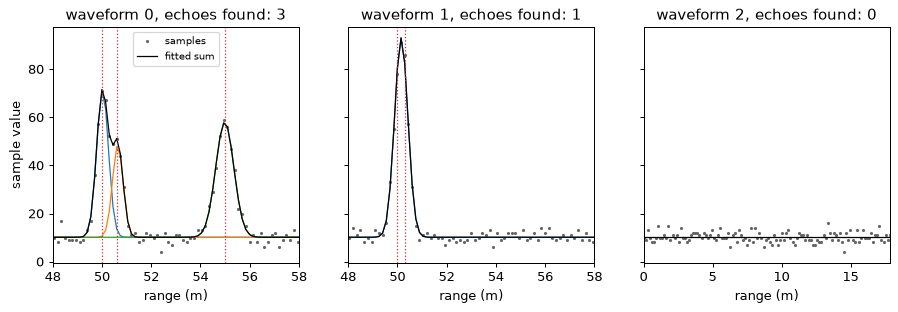

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for i, a in enumerate(ax):
    w = wf3[i]
    r = w.positions()[:, 2] * -1                # range below the scanner, along the beam
    a.plot(r, w.samples, ".", ms=3, c="0.4", label="samples")
    k = echoes3.waveform == i
    bg = echoes3.stats["background"][i]
    model = np.full_like(r, bg)
    for t, amp, wid in zip(echoes3.time[k], echoes3.amplitude[k], echoes3.width[k]):
        g = amp * np.exp(-0.5 * ((w.times() - t) / wid) ** 2)
        a.plot(r, bg + g, lw=1)
        model += g
    a.plot(r, model, "k", lw=1, label="fitted sum")
    for rt in truth3.range[truth3.waveform == i]:
        a.axvline(rt, c="C3", ls=":", lw=1)
    a.set(xlim=(48, 58) if i < 2 else (r[0], r[-1]), xlabel="range (m)", title=f"waveform {i}, echoes found: {k.sum()}")
ax[0].set_ylabel("sample value"); ax[0].legend(fontsize=8);

## An airborne survey as waveforms

The targets are now the returns of a simulated airborne survey
(`synthetic.als_flight`) over a 50 m plot with ten trees: each pulse becomes a
shot from the scanner position through its returns, with the returns'
intensities as amplitudes. The noise is 2 sample units, so the weakest
returns are only a few times the noise.

In [4]:
rng = np.random.default_rng(0)
stems = [(x, y, 0.3, h) for x, y, h in
         zip(rng.uniform(5, 45, 10), rng.uniform(5, 45, 10), rng.uniform(10, 25, 10))]
scene = synthetic.forest(stems, size=50.0, ground_points=100, margin=0.0)
flight = synthetic.als_flight(scene, altitude=80.0, line_spacing=40.0, pulse_rate=20_000, bounds=(0, 0, 50, 50))

pts = flight.points                          # the returns of a pulse are consecutive and share gps_time
t = pts.attrs["gps_time"]
first = np.flatnonzero(np.r_[True, t[1:] != t[:-1]])
count = np.diff(np.r_[first, len(t)])
origin = flight.sensor_positions(t[first])
ranges = np.linalg.norm(pts.xyz - np.repeat(origin, count, axis=0), axis=1)
last = first + count - 1
direction = (pts.xyz[last] - origin) / ranges[last, None]
targets = Shots(origin, direction, first, count, ranges, {"amplitude": pts.attrs["intensity"] / 100.0})

wf, truth = synthetic.waveforms(targets, gps_time=t[first], noise=2.0, seed=1)
print(wf, "|", truth, "| amplitudes (5, 50, 95 %):", np.percentile(truth.amplitude, [5, 50, 95]).round(1))

Waveforms(n_waveforms=110,994, n_samples=13,319,280) | Echoes(n=124,804) | amplitudes (5, 50, 95 %): [ 30.9  79.5 144.5]


## Writing and reading LAS wave packets

`write_las` writes LAS 1.4 point format 9 with the wave packets in an
extended VLR (or, with `external=True`, in a `.wdp` file beside it).
`waveform.info` describes a file without reading its waveforms, and
`waveform.read` reads them back; `waveform.chunks` reads a bounded number at
a time for files larger than memory.

In [5]:
path = tmp / "flight_wdp.las"
wf.write_las(path)
info = waveform.info(path)
print(f"{path.stat().st_size / 1e6:.0f} MB;", {k: info[k] for k in ("version", "point_format", "n_records", "packets")})
print("descriptor:", info["descriptors"][1])

back = waveform.read(path)
print(back)
print("samples identical:", np.array_equal(back.samples, wf.samples),
      "| gps_time identical:", np.array_equal(back.gps_time, wf.gps_time),
      f"| largest shift of a first sample: {1000 * np.abs(back.sample_positions()[:len(wf.samples)] - wf.sample_positions()).max():.2f} mm")

33 MB; {'version': '1.4', 'point_format': 9, 'n_records': 110994, 'packets': 'internal'}
descriptor: {'bits_per_sample': 16, 'n_samples': 120, 'interval': 1.0, 'gain': 1.0, 'offset': 0.0, 'compression': 0}


Waveforms(n_waveforms=110,994, n_samples=13,319,280)


samples identical: True | gps_time identical: True | largest shift of a first sample: 0.50 mm


## Decomposition against the truth

The waveforms are decomposed chunk by chunk, as a large file would be. LAS
stores no scanner position, so the echoes of the file have a position but no
range; they are compared with the true targets by position, within the same
waveform.

In [6]:
parts, found_parts = [], []
for chunk in waveform.chunks(path, size=50_000):
    echoes = chunk.decompose()
    found_parts.append(echoes)
    parts.append(echoes.to_shots(chunk, origin=flight.sensor_positions(chunk.gps_time)))
shots = Shots.concatenate(parts)
print(shots)

echoes = back.decompose()                    # the whole file at once, for the comparison
lo = np.searchsorted(echoes.waveform, truth.waveform, "left")
hi = np.searchsorted(echoes.waveform, truth.waveform, "right")
miss = np.full(len(truth), np.inf)
for i in np.flatnonzero(hi > lo):
    miss[i] = np.linalg.norm(echoes.xyz[lo[i]:hi[i]] - truth.xyz[i], axis=1).min()
found = miss < 0.3
print(f"{len(echoes):,} echoes found for {len(truth):,} targets; {found.mean():.1%} of the targets "
      f"have an echo within 0.3 m, a median {1000 * np.median(miss[found]):.1f} mm away")
last_sample = wf.anchor + wf.direction * (wf.metres_per_ns * (wf.offset + (wf.sample_count - 1) * wf.interval))[:, None]
record_end = np.linalg.norm(last_sample - origin, axis=1)      # range of each waveform's last sample
inside = truth.range <= record_end[truth.waveform]
print(f"{(~inside).sum():,} targets ({(~inside).mean():.1%}) lie beyond the end of their digitised record; "
      f"of the {inside.sum():,} inside it, {found[inside].mean():.1%} are found")
snr = truth.amplitude / echoes.stats["noise"].mean()
for a, b in ((0, 6), (6, 10), (10, np.inf)):
    k = inside & (snr >= a) & (snr < b)
    print(f"  amplitude {a:>2} to {b:<4} times the noise: {k.sum():>7,} targets in the record, {found[k].mean():6.1%} found, "
          f"median distance {1000 * np.median(miss[k & found]):5.1f} mm")

Shots(n_shots=110,994, n_echoes=118,606)


118,606 echoes found for 124,804 targets; 95.0% of the targets have an echo within 0.3 m, a median 3.4 mm away
6,084 targets (4.9%) lie beyond the end of their digitised record; of the 118,720 inside it, 99.7% are found
  amplitude  0 to 6    times the noise:     670 targets in the record,  57.6% found, median distance  26.9 mm
  amplitude  6 to 10   times the noise:     370 targets in the record,  94.3% found, median distance  16.1 mm
  amplitude 10 to inf  times the noise: 117,680 targets in the record, 100.0% found, median distance   3.4 mm


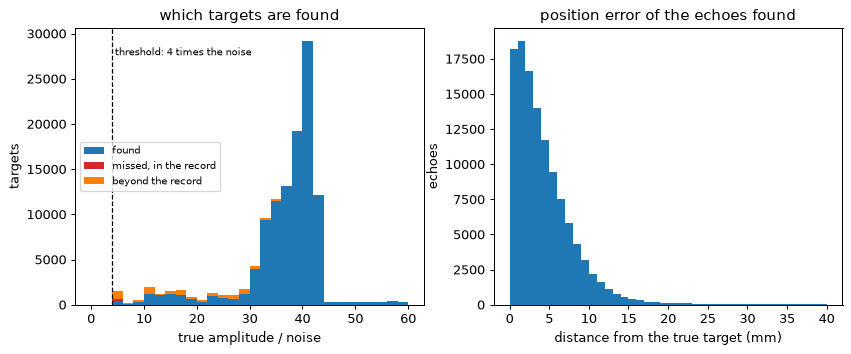

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(0, 60, 31)
ax[0].hist([snr[found], snr[~found & inside], snr[~inside]], bins, stacked=True, color=["C0", "C3", "C1"],
           label=["found", "missed, in the record", "beyond the record"])
ax[0].axvline(4, c="k", ls="--", lw=1)
ax[0].text(4.5, ax[0].get_ylim()[1] * 0.9, "threshold: 4 times the noise", fontsize=8)
ax[0].set(xlabel="true amplitude / noise", ylabel="targets", title="which targets are found"); ax[0].legend(fontsize=8)
ax[1].hist(1000 * miss[found], np.linspace(0, 40, 41), color="C0")
ax[1].set(xlabel="distance from the true target (mm)", ylabel="echoes", title="position error of the echoes found");

Within the digitised record, the targets missed are the weak ones, below
or near the detection threshold of four noise standard deviations; those
found lie within millimetres of the truth. Most of the targets missed,
however, were never digitised: `synthetic.waveforms` records 120 samples at
1 ns from 3 m before a pulse's first target, which covers 18 m of range, so a
ground return more than 15 m below the first canopy return falls beyond the
end of the record. Almost all of these (98 %) are ground returns under tall
crowns; a longer record (`n_samples`) keeps them. A real scanner's
record length sets the same limit, and it is worth checking against the
canopy height before a survey's waveforms are used for canopy structure.

## From echoes to ray-traced voxels

`to_shots` makes one shot per pulse with its echoes sorted by range; a pulse
in which nothing was found stays a shot without an echo, which the tracer
counts as free space. With origins from the trajectory, the shots go straight
into `voxels.ray_voxelize`. For comparison, the discrete returns of the same
flight are made into pulses with `als.pulses`.

In [8]:
box = ((0, 0, -2), (50, 50, 30))
grid_wf = voxels.ray_voxelize(shots, 1.0, box)
grid_dr = voxels.ray_voxelize(als.pulses(pts, als.Trajectory.from_dict(flight.trajectory)), 1.0, box)
grid_tr = voxels.ray_voxelize(truth.to_shots(wf, origin=flight.sensor_positions(wf.gps_time)), 1.0, box)
print(grid_wf)
z = grid_wf.z_levels() + 0.5
pad = {name: g.profile("pad_fpl") for name, g in
       (("waveform echoes", grid_wf), ("discrete returns", grid_dr), ("true targets", grid_tr))}
print("true targets and discrete returns give the same profile:",
      np.allclose(pad["true targets"], pad["discrete returns"], equal_nan=True))
k = (z > 5) & (z < 25)
print(f"mean PAD 5-25 m: waveform {np.nanmean(pad['waveform echoes'][k]):.4f}, "
      f"discrete {np.nanmean(pad['discrete returns'][k]):.4f} m² m⁻³")

RayVoxelGrid(50x50x32 @ 1 m)
true targets and discrete returns give the same profile: True
mean PAD 5-25 m: waveform 0.0169, discrete 0.0136 m² m⁻³


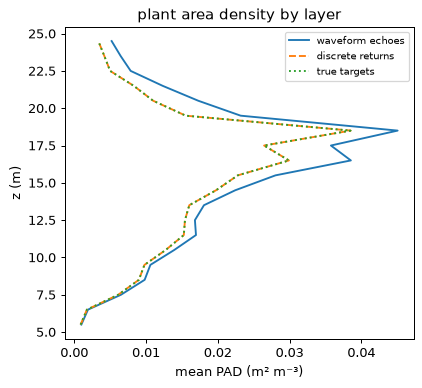

In [9]:
fig, ax = plt.subplots(figsize=(5, 4.5))
for (name, p), style in zip(pad.items(), ("-", "--", ":")):
    ax.plot(p[k], z[k], style, label=name)
ax.set(xlabel="mean PAD (m² m⁻³)", ylabel="z (m)", title="plant area density by layer")
ax.legend(fontsize=8);

The pulses built from the true targets reproduce the discrete-return pulses
exactly, so the difference between the waveform and discrete profiles comes
entirely from the echoes the decomposition missed. A pulse that loses an
echo gives its remaining echoes a larger share of the pulse and, when the echo
lost was its last, ends earlier; both raise the density read in the canopy. The same
effect is present, and not visible, in a discrete-return survey whose
detector drops weak returns; a waveform survey at least lets the threshold
be chosen and its effect measured.